# Fixed points of feedback diagrams

A diagram with a feedback loop has stream semantics — `to_stream` and
`unroll` give it at each finite time — and approximate fixed-point semantics
through `fix`, which estimates the state the loop settles into. Both are built
from the same open one-step channel.

## Part 1: one beam splitter, one photon per step

The smallest instance worth studying. A photon enters the first input at every
step; the second output is fed back into the second input.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from discopy.symmetric import Equation
from optyx import photonic
from optyx.channel import Channel, Diagram, Discard, qmode
from optyx.core import diagram
from optyx.core.backends import DiscopyBackend

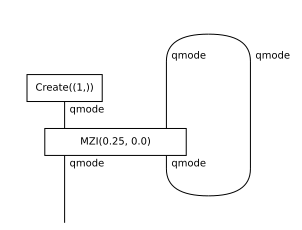

In [2]:
def learner(theta, phi=0.0):
    return (photonic.Create(1) @ qmode >> photonic.MZI(theta, phi)).feedback(
        mem=qmode, initial_state=photonic.Create(0))

learner(0.25).draw(figsize=(4, 3))

Photon number is conserved and the drive has a definite number, so the loop
and output occupations are perfectly correlated: tracing out one destroys
every coherence between different photon numbers. The fixed point is
**diagonal in the Fock basis**, and the external phase `phi`, being diagonal
in number, cannot affect it.

In [3]:
rho = learner(.06, .125).fix(method="eigen", chi=8).density_matrix
off_diagonal = np.abs(rho - np.diag(np.diag(rho))).max()
print(f"largest off-diagonal element: {off_diagonal:.2e}")

base = learner(.06, 0).fix(method="eigen", chi=8).density_matrix
for phi in (0, .125, .25, .5, .75):
    other = learner(.06, phi).fix(method="eigen", chi=8).density_matrix
    print(f"phi={phi:5.3f}  max difference from phi=0: "
          f"{np.abs(other - base).max():.2e}")

largest off-diagonal element: 0.00e+00


phi=0.000  max difference from phi=0: 0.00e+00


phi=0.125  max difference from phi=0: 2.22e-16


phi=0.250  max difference from phi=0: 2.22e-16


phi=0.500  max difference from phi=0: 1.11e-16


phi=0.750  max difference from phi=0: 2.22e-16


### The mean is exactly one

With $b_{\mathrm{out}}=-r^*a_{\mathrm{in}}+t^*b_{\mathrm{in}}$, a Fock input
and a number-diagonal memory kill the cross terms, so $\bar n'=R+T\bar n$ and
the fixed point forces $\langle n\rangle=1$: one photon in per step, one out.
Writing $T$ for the probability that the fresh photon leaves immediately, the
variance is $4T/(1+T)$ — exactly twice the $2T/(1+T)$ of distinguishable
particles undergoing the same binomial thinning. Bunching doubles the variance
and leaves the mean alone.

In [4]:
def statistics(distribution):
    n = np.arange(len(distribution))
    mean = (n * distribution).sum()
    return mean, (n * n * distribution).sum() - mean ** 2


records = []
for theta, cutoff in ((.02, 6), (.04, 7), (.06, 8), (.08, 9)):
    rho = learner(theta).fix(method="eigen", chi=cutoff).density_matrix
    p = np.real(np.diag(rho))
    p = p / p.sum()
    mean, variance = statistics(p)
    records.append((theta, np.sin(np.pi * theta) ** 2, mean, variance - mean, p))
    print(f"theta={theta:.2f}  T={np.sin(np.pi*theta)**2:.4f}  "
          f"mean={mean:.6f}  Q={variance-mean:+.6f}")

theta=0.02  T=0.0039  mean=1.000000  Q=-0.968707


theta=0.04  T=0.0157  mean=1.000000  Q=-0.878220


theta=0.06  T=0.0351  mean=1.000000  Q=-0.738162


theta=0.08  T=0.0618  mean=1.000000  Q=-0.562862


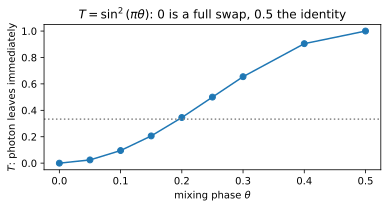

In [5]:
thetas = np.array([0, .05, .1, .15, .2, .25, .3, .4, .5])
transmission = []
for theta in thetas:
    amps = (photonic.Create(1, 0) >> photonic.MZI(theta, 0)
            ).eval(DiscopyBackend()).amplitudes()
    transmission.append(abs(amps.get((1, 0), 0)) ** 2)
transmission = np.array(transmission)

figure, axis = plt.subplots(figsize=(5.5, 3))
axis.plot(thetas, transmission, "o-")
axis.axhline(1 / 3, ls=":", color="grey")
axis.set_xlabel(r"mixing phase $\theta$")
axis.set_ylabel(r"$T$: photon leaves immediately")
axis.set_title(r"$T=\sin^2(\pi\theta)$: 0 is a full swap, 0.5 the identity")
figure.tight_layout()
plt.show()

$\theta=0$ is a full swap: the loop holds exactly one photon forever.
$\theta=0.5$ is the identity: the photon leaves and the loop never fills.

### The stationary distribution and its tail

Only the full swap gives a single Fock state. For every $T>0$ the fixed point
has weight on every photon number; what changes is how fast the tail decays.

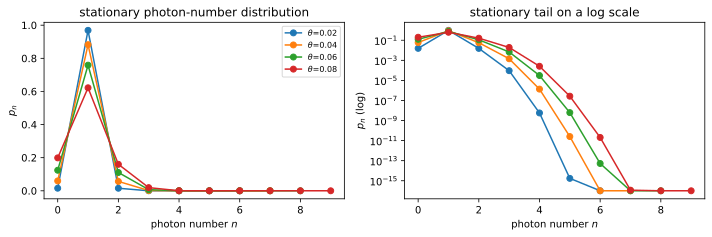

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for theta, T, mean, Q, p in records:
    occupations = np.arange(len(p))
    axes[0].plot(occupations, p, "o-", label=fr"$\theta$={theta:.2f}")
    axes[1].semilogy(occupations, np.maximum(p, 1e-16), "o-")
axes[0].set_xlabel("photon number $n$")
axes[0].set_ylabel("$p_n$")
axes[0].set_title("stationary photon-number distribution")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("photon number $n$")
axes[1].set_ylabel("$p_n$ (log)")
axes[1].set_title("stationary tail on a log scale")
figure.tight_layout()
plt.show()

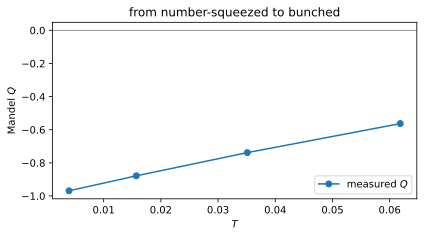

In [7]:
figure, axis = plt.subplots(figsize=(6, 3.4))
axis.plot([r[1] for r in records], [r[3] for r in records], "o-",
          label="measured $Q$")
axis.axhline(0, color="grey", lw=.8)
axis.set_xlabel("$T$")
axis.set_ylabel("Mandel $Q$")
axis.set_title("from number-squeezed to bunched")
axis.legend()
figure.tight_layout()
plt.show()

### What this state is not

The fixed point is a classical mixture of Fock states with mean exactly one,
and it belongs to none of the usual families. Not **coherent**: it is
Fock-diagonal, while a coherent state is pure with large coherences. Not
**Poissonian**: $Q=\mathrm{Var}(N)-\langle N\rangle$ runs from $-1$ at the
full swap to $+1$ as the loop decouples, and where it crosses zero only the
second moment matches, not the distribution. Not **thermal**, which would need
$Q=+1$ throughout. And not **Gaussian**, because the only Fock-diagonal
single-mode Gaussian states are the thermal ones — so being Gaussian would
mean being thermal. Its factorial moments are $F_r=r!\,F_r^{\mathrm C}$
against the distinguishable chain, reaching the thermal $r!$ only as
$T\to1$.

## Part 2: complexity of stationary boson sampling

Now the general problem. Let $U$ be an arbitrary number-preserving unitary on
$M+L$ modes. At every time step the $M$ external inputs carry a fixed product
state $\psi$, the $L$ remaining inputs carry the loop, $M$ outputs are
detected and $L$ outputs are fed back. **Stationary boson sampling** asks for
the output distribution once this has settled.

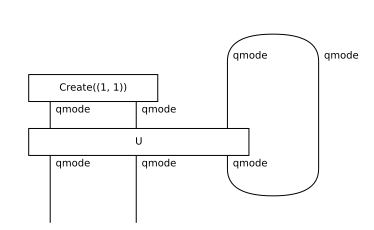

In [8]:
def random_unitary(size, seed=7):
    rng = np.random.default_rng(seed)
    matrix = rng.normal(size=(size, size)) + 1j * rng.normal(size=(size, size))
    unitary, upper = np.linalg.qr(matrix)
    return unitary * (np.diag(upper) / np.abs(np.diag(upper)))


U = photonic.Gate(random_unitary(3), 3, 3, "U")

def feedback_sampler(occupation):
    psi = photonic.Create(*occupation)
    return (psi @ qmode >> U).feedback(
        mem=qmode, initial_state=photonic.Create(0))

process = feedback_sampler((1, 1))
process.draw(figsize=(5, 3))

One step contains the two maps. Tracing out the detected modes updates the
loop, $\rho\mapsto\mathrm{Tr}_M[U(|\psi\rangle\langle\psi|\otimes\rho)
U^\dagger]$; tracing out the next loop instead gives the visible output.
`power` iterates the first and reads out once; `eigen` builds the transfer
operator of the first, solves for its stationary $\rho_\star$, and reads out
once.

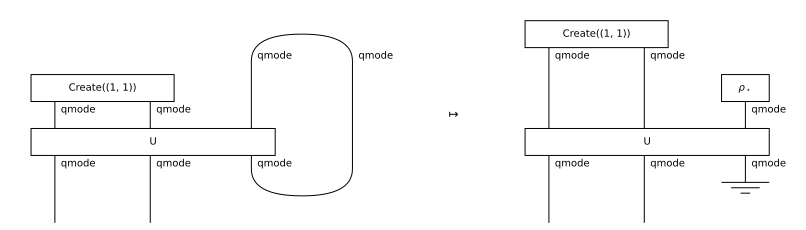

In [9]:
stationary = Channel(
    r"$\rho_\star$",
    diagram.Box(r"$\rho_\star$", diagram.Ty(), diagram.Mode(2)),
    cod=qmode, env=diagram.Mode(1))
readout = (photonic.Create(1, 1) @ stationary >> U
           >> Diagram.id(qmode ** 2) @ Discard(qmode))
Equation(process, readout, symbol=r"$\mapsto$").draw(figsize=(11, 3))

### Time and space

Take $\psi=|1\rangle^{\otimes M}$ and run $n$ steps. At most $M$ photons enter
per step, so after $n$ steps the loop holds at most $nM$ photons and its
truncated dimension is

$$h(L,n,M)=\binom{nM+L}{L}\sim\frac{(nM)^{L}}{L!}.$$

Write $\mathrm{cost}(U)$ and $\mathrm{space}(U)$ for one application of the
doubled one-step channel. **As algorithms**:

| | time | space |
| --- | --- | --- |
| `power` | $O(n\,\mathrm{cost}(U))$ | $O(h^2+\mathrm{space}(U))$ |
| `eigen` | $O(h^2\,\mathrm{cost}(U)+h^6)$ | $O(h^4+\mathrm{space}(U))$ |

Space is the sharper separator. Power holds one density matrix on the loop,
$h^2$ numbers, and overwrites it each step. Eigen materialises the whole
transfer operator, an $h^2\times h^2$ matrix, so $h^4$ numbers — the square of
what power needs. That is what actually stops eigen first: the $h^4$ array
exhausts memory long before the $h^6$ solve exhausts patience, which is why
the truncation check refuses at cutoffs the timing study can still reach.

Two corrections to the time column, both forced by measurement:

* the $h^6$ eigensolve **never dominates at reachable sizes**, so eigen is
  *build-dominated* and scales like $h^2$, not $h^6$;
* power is **not linear in $n$ as implemented**: `fix` unrolls the history
  into one network and contracts it, rather than applying the channel to a
  density matrix once per step.

In [10]:
import time

cutoffs, eigen_times = [], []
for cutoff in (6, 7, 8, 9, 10):
    try:
        start = time.perf_counter()
        learner(.02).fix(method="eigen", chi=cutoff)
        eigen_times.append(time.perf_counter() - start)
        cutoffs.append(cutoff + 1)
    except ValueError:
        pass
eigen_slope = np.polyfit(np.log(cutoffs), np.log(eigen_times), 1)[0]

depths, power_times, widths, swaps = (2, 4, 6, 8), [], [], []
for depth in depths:
    start = time.perf_counter()
    learner(.02).fix(n_steps=depth, chi=8, backend=DiscopyBackend())
    power_times.append(time.perf_counter() - start)
    network = learner(.02).at_time(depth).double().to_tensor()
    widths.append(len(network.boxes))
    swaps.append(sum(1 for b in network.boxes if type(b).__name__ == "Swap"))
power_slope = np.polyfit(np.log(np.array(depths, float)),
                         np.log(power_times), 1)[0]
size_slope = np.polyfit(np.log(np.array(depths, float)),
                        np.log(widths), 1)[0]
swap_slope = np.polyfit(np.log(np.array(depths, float)),
                        np.log(swaps), 1)[0]

print(f"eigen : exponent in h  = {eigen_slope:.2f}"
      "   (h^2 build predicted 2, h^6 solve predicted 6)")
print(f"power : exponent in n  = {power_slope:.2f}"
      "   (one application per step predicts 1)")
print(f"        boxes {widths}, exponent {size_slope:.2f}")
print(f"        swaps {swaps}, exponent {swap_slope:.2f}")

eigen : exponent in h  = 2.02   (h^2 build predicted 2, h^6 solve predicted 6)
power : exponent in n  = 1.83   (one application per step predicts 1)
        boxes [68, 136, 212, 296], exponent 1.06
        swaps [8, 22, 44, 74], exponent 1.60


The eigen exponent lands near $2$, not $6$: the dense solve never gets to
dominate, so the build is the whole story and the $h^6$ term is asymptotic
decoration at any size this implementation can reach.

The power exponent sits well above $1$, and the box counts say where it does
*not* come from: the network grows essentially linearly in the depth, so this
is not a case of building a bigger diagram than necessary. Two things are
superlinear instead. The swap count grows faster than the depth — every step
adds an output wire that later steps must route past — and, contracted
exactly, the intermediate tensors grow as the contraction sweeps through the
history, so the cost per box rises with depth. Bounding the bond dimension
addresses the second; the first is pure routing, which a combinatorial-map
contraction removes by turning wire routing into index naming rather than
tensors.

Up to constants, simulation time follows the corrected costs — $h^2$ for
eigen, superlinear in $n$ for power — and not the idealised ones.

### Definitions

Everything below is stated in terms of five objects, so they are worth fixing
precisely.

**The unitary and its blocks.** $U$ is an $(M+L)\times(M+L)$ unitary acting on
mode operators, $a_i\mapsto\sum_j U_{ij}a_j$; it is passive, so it preserves
total photon number. Order the modes external-first, so

$$U=\begin{pmatrix}A & B\\ C & D\end{pmatrix},$$

with $A$ the $M\times M$ external-to-external block and $D$ the $L\times L$
**loop block**: $D_{ij}$ is the amplitude for a photon in loop mode $j$ to
stay in the loop, arriving in mode $i$. Its singular values are
$s_1\ge\cdots\ge s_L$, and $s_1=\|D\|$. Since $D$ is a sub-block of a unitary,
$s_1\le1$.

**The step channel.** With $\psi=|1\rangle^{\otimes M}$ injected on the
external inputs each step,

$$\Phi:\;\rho\;\longmapsto\;\operatorname{Tr}_M\!\big[
U(\psi\otimes\rho)U^\dagger\big]$$

is a CPTP map on states of the $L$ loop modes. $\rho_\star$ denotes a fixed
point, $\Phi(\rho_\star)=\rho_\star$.

**The loop chain and $h$.** Truncating each loop mode at $c$ photons gives the
loop a Hilbert space of dimension $h=c^L$ (or $h=\binom{nM+L}{L}$ under a
total-photon truncation, the form used in the cost table). Because $\Phi$
preserves Fock-diagonality, it restricts to a classical Markov chain on the
$h$ loop occupations, with transition matrix

$$P_{\mathbf m\mathbf n}
=\Pr[\text{loop}=\mathbf n\text{ after one step}\mid\text{loop}=\mathbf m],$$

obtained by applying $U$ to $|\psi,\mathbf m\rangle$ and summing $|\text{
amplitude}|^2$ over all external outcomes.

**$\lambda_2$.** $P$ is stochastic, so its eigenvalues satisfy
$1=|\lambda_1|\ge|\lambda_2|\ge\cdots$. We write $|\lambda_2|$ for the
second-largest eigenvalue *modulus* of $P$ — the **spectral gap** is
$1-|\lambda_2|$. It sets the asymptotic rate: $\|P^n(\mathbf m,\cdot)-\pi\|
\sim|\lambda_2|^n$ as $n\to\infty$, with $\pi$ the stationary distribution.
Taking $P$ rather than the full superoperator is the right choice here, and is
justified above: a Fock-diagonal start never leaves the population sector.

**$\eta$ and $n^\star$.** $\eta$ is the Dobrushin coefficient of $P$ defined
below, a bound valid at *every* $n$ rather than asymptotically. Given a target
total-variation error $\varepsilon$, the certified depth is
$n^\star(\varepsilon)=\lceil\log\varepsilon/\log\eta\rceil$, and the
asymptotic estimate replaces $\eta$ by $|\lambda_2|$.

In Part 1, $L=M=1$ and $D$ is the single number with $|D|^2=T$, which is why
$|\lambda_2|=T$ there.

### How long until it converges

Cost per step is half the question; the other half is how many steps. Write

$$\Phi_{U,\psi,L,M}:\;\rho\;\longmapsto\;
\operatorname{Tr}_M\!\big[U(\psi\otimes\rho)U^\dagger\big]$$

for one step of the general problem, a CPTP map on the $L$ loop modes. This is
a *quantum Markov chain* in the collision-model sense — a system meeting a
fresh ancilla $\psi$ at each step and the ancilla being discarded — so the
convergence theory for those applies (Ciccarello et al. 2022).

Three standard facts set what we can hope for. Every CPTP map is a contraction
in trace norm, so the distance to a fixed point never grows (Pérez-García et
al. 2006). If the fixed point $\rho_\star$ is unique, the asymptotic rate is
the second-largest eigenvalue modulus $|\lambda_2|$ of $\Phi$. But
$|\lambda_2|^n$ is **not** an upper bound at finite $n$: $\Phi$ is not normal,
and spectral estimates for non-normal Markov maps need the Jordan structure,
not just the spectrum (Szehr, Reeb and Wolf 2015). So $|\lambda_2|$ predicts
the depth an unrolling *eventually* needs, while a certified depth needs the
norm quantity of the next section.

The one-mode loop of Part 1 is the special case $L=M=1$ with a beam splitter,
and there the spectrum is elementary: $|\lambda_2|=T$, the survival
probability.

In [11]:
from scipy.linalg import expm

def loop_chain(T, cutoff=20):
    ladder = np.diag(np.sqrt(np.arange(1, cutoff + 1)), 1)
    identity = np.eye(cutoff + 1)
    a, b = np.kron(ladder, identity), np.kron(identity, ladder)
    unitary = expm(np.arcsin(np.sqrt(1 - T)) * (a.conj().T @ b - a @ b.conj().T))
    chain = np.zeros((cutoff + 1, cutoff + 1))
    for n in range(cutoff):
        vector = np.zeros((cutoff + 1) ** 2)
        vector[cutoff + 1 + n] = 1.0
        chain[n] = (np.abs((unitary @ vector).reshape(
            cutoff + 1, cutoff + 1)) ** 2).sum(axis=0)
    chain = chain[:cutoff, :cutoff]
    return chain / chain.sum(axis=1, keepdims=True)

print("   T    |lambda_2|      T      n* for eps = 1e-6")
for T in (0.1, 0.2, 0.4, 0.6, 0.8):
    moduli = np.sort(np.abs(np.linalg.eigvals(loop_chain(T).T)))[::-1]
    second = moduli[1]
    print(f" {T:4.2f}    {second:.6f}   {T:.4f}"
          f"        {np.log(1e-6) / np.log(second):8.1f}")

   T    |lambda_2|      T      n* for eps = 1e-6


 0.10    0.100000   0.1000             6.0
 0.20    0.200000   0.2000             8.6


 0.40    0.400000   0.4000            15.1


 0.60    0.600000   0.6000            27.0
 0.80    0.800000   0.8000            61.9


$|\lambda_2|=T$ to six digits, so $n^\star=\log\varepsilon/\log T$: a loop
that retains more takes proportionally longer to forget its initial state, and
`power` costs $n^\star$ times its per-step cost rather than a free parameter.

### Haar-random $U$ at small $L$ and $M$

The one-mode case is too special to generalise from, so measure the transfer
operator directly for a Haar-random $U$ on $M+L$ modes, with $|1\rangle^{
\otimes M}$ injected each step. Two spectra matter, and they are not the same
one. The **full** superoperator acts on all of the loop's density matrices;
its second eigenvalue is the worst case over arbitrary initial states. But the
dynamics preserves Fock-diagonality — photon-number conservation again — so a
Fock-diagonal start never leaves the **population** sector, and only that
sector's second eigenvalue can be excited.

In [12]:
from scipy.linalg import logm

def ladder(cutoff, modes, which):
    single = np.diag(np.sqrt(np.arange(1, cutoff)), 1)
    out = np.array([[1.0]])
    for mode in range(modes):
        out = np.kron(out, single if mode == which else np.eye(cutoff))
    return out

def fock_unitary(matrix, cutoff):
    modes = matrix.shape[0]
    generator, a = logm(matrix), [
        ladder(cutoff, modes, m) for m in range(modes)]
    total = np.zeros((cutoff ** modes,) * 2, dtype=complex)
    for i in range(modes):
        for j in range(modes):
            total += generator[i, j] * (a[i].conj().T @ a[j])
    return expm(total)

def haar(size, seed):
    generator = np.random.default_rng(seed)
    z = generator.normal(size=(size, size)) + 1j * generator.normal(
        size=(size, size))
    q, r = np.linalg.qr(z)
    return q * (np.diag(r) / np.abs(np.diag(r)))

def transfer_operator(M, L, cutoff, seed=1):
    """One step |1>^M (x) rho -> Tr_M[U(...)U^dag] as a matrix on rho."""
    unitary = haar(M + L, seed)
    evolution = fock_unitary(unitary, cutoff)
    dimension, loop, external = cutoff ** (M + L), cutoff ** L, cutoff ** M
    index = 0
    for _ in range(M):
        index = index * cutoff + 1
    injected = np.zeros(external)
    injected[index] = 1.0
    operator = np.zeros((loop * loop, loop * loop), dtype=complex)
    for row in range(loop):
        for column in range(loop):
            state = np.zeros((loop, loop), dtype=complex)
            state[row, column] = 1.0
            full = np.kron(np.outer(injected, injected), state).reshape(
                dimension, dimension)
            evolved = (evolution @ full @ evolution.conj().T).reshape(
                external, loop, external, loop)
            operator[:, row * loop + column] = np.trace(
                evolved.transpose(1, 3, 0, 2), axis1=2, axis2=3).reshape(-1)
    return operator, unitary

def population_block(operator, loop):
    block = np.zeros((loop, loop))
    for i in range(loop):
        block[i] = np.real(np.diag(
            operator[:, i * loop + i].reshape(loop, loop)))
    return block

print(" M  L   |l1|     |l2| full   |l2| population   s1^2    n*(1e-4)")
studies = {}
for M, L, cutoff in ((1, 1, 6), (2, 1, 5), (2, 2, 4)):
    operator, unitary = transfer_operator(M, L, cutoff)
    loop = cutoff ** L
    moduli = np.sort(np.abs(np.linalg.eigvals(operator)))[::-1]
    populations = np.sort(np.abs(np.linalg.eigvals(
        population_block(operator, loop).T)))[::-1]
    squared = np.linalg.svd(unitary[M:, M:], compute_uv=False)[0] ** 2
    steps = int(np.ceil(np.log(1e-4) / np.log(populations[1])))
    studies[M, L] = (operator, loop, populations[1], steps)
    print(f" {M}  {L}  {moduli[0]:.6f}   {moduli[1]:.6f}     {populations[1]:.6f}"
          f"      {squared:.4f}   {steps:5d}")


 M  L   |l1|     |l2| full   |l2| population   s1^2    n*(1e-4)
 1  1  1.000000   0.810747     0.649925      0.7026      22


 2  1  1.000000   0.698321     0.506888      0.5948      14


 2  2  1.000000   0.451975     0.465658      0.8199      13


In [13]:
print(" M  L   n*    error at n*   error at 2n*   measured rate")
for (M, L), (operator, loop, rate, steps) in studies.items():
    values, vectors = np.linalg.eig(operator)
    fixed = vectors[:, np.argmin(np.abs(values - 1))].reshape(loop, loop)
    fixed = fixed / np.trace(fixed)
    vector = np.zeros((loop, loop), dtype=complex)
    vector[0, 0] = 1.0
    vector = vector.reshape(-1)
    errors = {}
    for step in range(1, 2 * steps + 1):
        vector = operator @ vector
        state = vector.reshape(loop, loop)
        errors[step] = np.linalg.norm(state / np.trace(state) - fixed)
    window = [s for s in errors if steps // 2 <= s <= steps and s > 1]
    measured = np.exp(np.polyfit(
        window, [np.log(errors[s]) for s in window], 1)[0])
    print(f" {M}  {L}  {steps:4d}   {errors[steps]:.2e}     "
          f"{errors[2 * steps]:.2e}     {measured:.4f}")


 M  L   n*    error at n*   error at 2n*   measured rate
 1  1    22   2.72e-05     2.08e-09     0.6499
 2  1    14   2.95e-05     2.18e-09     0.5069
 2  2    13   2.35e-05     7.68e-10     0.4509


Three things come out of this, and one of them kills a plausible guess.

**The unrolling does reproduce the fixed point.** Running to $n^\star$ reaches
the $10^{-4}$ target in every case, and doubling the depth squares the error —
the signature of geometric convergence. So the recipe works: measure the gap,
read off $n^\star$, unroll that far.

**The rate is the population eigenvalue, not the full one.** The measured
decay matches $|\lambda_2|$ of the population sector to four digits, while the
full superoperator's $|\lambda_2|$ is strictly larger. Using the full spectrum
is safe but wasteful: it predicts a depth at which the error is already orders
of magnitude below target. The reason is structural — a Fock-diagonal state
stays Fock-diagonal, so the coherence eigenvalues are never excited from a
physical start.

**The singular-value guess is wrong.** One might hope $|\lambda_2|\approx
s_1^2$, the largest singular value of the loop block of $U$, since that is
exactly $T$ for the one-mode beam splitter. The measurement refutes it: the
two disagree in every Haar case, and for $L=2$ the loop block can have
$s_1\approx1$ while the channel still mixes at $0.96$. The single-photon
picture does not survive contact with many photons, and $|\lambda_2|$ has to
be measured rather than read off $U$.

That last point is what makes the reduction question below hard: without a
formula for the gap in terms of $U$, $M$ and $L$, whether $n^\star$ stays
polynomial is an empirical question about Haar-random channels.

### A bound you can actually certify

To *choose* a depth and be sure, we want $\eta$ with

$$\big\|\Phi^n_{U,\psi,L,M}(\rho)-\rho_\star\big\|_1\;\le\;
\eta^{\,n}\,\|\rho-\rho_\star\|_1\quad\text{for every }n,$$

giving a certified $n^\star=\log\varepsilon/\log\eta$. Such an $\eta$ is a
**contraction (ergodicity) coefficient**: submultiplicative, so one evaluation
bounds every power, and $\eta\ge|\lambda_2|$ always, since a norm dominates a
spectral radius.

For the general channel this is the trace-norm contraction coefficient, whose
exact evaluation is expensive. Here it collapses to something cheap, and the
reason is the structure established in Part 1 rather than anything about beam
splitters: $U$ is number-preserving and $\psi=|1\rangle^{\otimes M}$ has
definite photon number, so $\Phi_{U,\psi,L,M}$ maps Fock-diagonal states to
Fock-diagonal states for **any** $L$ and $M$. The dynamics therefore lives in
the population sector, where the trace-norm contraction coefficient is exactly
the classical **Dobrushin coefficient** (Dobrushin 1956)

$$\eta=\tfrac12\max_{i,j}\;\sum_k\big|P_{ik}-P_{jk}\big|,$$

the largest total-variation distance between two rows of the one-step
transition matrix $P$ on loop occupations.

In [14]:
def dobrushin(chain):
    stochastic = chain / np.maximum(chain.sum(axis=1, keepdims=True), 1e-15)
    return max(0.5 * np.abs(stochastic[i][None, :] - stochastic).sum(
        axis=1).max() for i in range(len(stochastic)))

print(" M  L   |l2| pop    eta      eta >= |l2|   n*(eta)   error at n*(eta)")
for (M, L), (operator, loop, rate, _) in studies.items():
    chain = population_block(operator, loop)
    eta = dobrushin(chain)
    steps = int(np.ceil(np.log(1e-4) / np.log(eta)))
    values, vectors = np.linalg.eig(operator)
    fixed = vectors[:, np.argmin(np.abs(values - 1))].reshape(loop, loop)
    fixed = fixed / np.trace(fixed)
    vector = np.zeros((loop, loop), dtype=complex)
    vector[0, 0] = 1.0
    vector = vector.reshape(-1)
    for _ in range(steps):
        vector = operator @ vector
    state = vector.reshape(loop, loop)
    error = np.linalg.norm(state / np.trace(state) - fixed)
    print(f" {M}  {L}   {rate:.6f}  {eta:.6f}      {eta >= rate}"
          f"      {steps:5d}      {error:.2e}")


 M  L   |l2| pop    eta      eta >= |l2|   n*(eta)   error at n*(eta)
 1  1   0.649925  0.895232      True         84      6.73e-16
 2  1   0.506888  0.645035      True         22      1.28e-07
 2  2   0.465658  0.899288      True         87      2.57e-16


$\eta$ dominates $|\lambda_2|$ in every case, as it must, and the depth it
prescribes always clears the $10^{-4}$ target with room to spare. That is the
point: $n^\star(\eta)$ is a *certificate* rather than an estimate, so an
unrolling run to that depth is guaranteed to approximate the limiting process,
whereas $n^\star(|\lambda_2|)$ is only asymptotically justified.

**Is it cheap?** Cheaper than solving for the fixed point, which is what makes
it useful. Building $P$ costs $h$ channel applications, one per loop basis
state, and the pairwise maximum is $O(h^2)$ arithmetic. Compare eigen, which
needs $h^2$ applications to build the full superoperator and then a dense
solve:

| | channel applications | extra arithmetic | space |
| --- | --- | --- | --- |
| $\eta$ (certified depth) | $O(h)$ | $O(h^2)$ | $O(h^2)$ |
| `eigen` (the fixed point) | $O(h^2)$ | $O(h^6)$ | $O(h^4)$ |

So a depth can be certified in regimes where `eigen` is out of reach, and
`power` then run to exactly that depth.

**Which parameter binds.** Everything here is driven by $h\sim(nM)^L/L!$: the
loop dimension is *polynomial in $M$ at fixed $L$ and exponential in $L$*. So
$M$ is cheap and $L$ is expensive, and this is the one asymmetry that governs
the whole of Part 2 — the cost table, the certificate, and the mixing results
below all inherit it. It also means a bound polynomial in both cannot be read
off $P$ at all; it has to come from $U$.

Two routes, neither settled here. The **drift** route: a loop photon survives a
step with probability at most $s_1^2$, the top singular value of the loop block
of $U$, and at most $M$ photons enter, so $\mathbb E[N_{t+1}]\le s_1^2\,
\mathbb E[N_t]+M$ — computable in $O((M+L)^3)$, enough to fix the Fock cutoff,
but a bound on occupation rather than on total-variation mixing. The
**path-coupling** route is more promising: a quantum analogue of the Dobrushin
condition, under which path coupling gives rapid mixing for quantum Markov
chains (Bakshi, Liu, Moitra and Tang 2025). Its condition is local, so for
$\Phi_{U,\psi,L,M}$ it would become a statement about the loop block of $U$ —
a quantity that stays tractable as $L$ grows. Checking it is the concrete next
step.

Note that the refuted $s_1^2$ guess is a warning against assuming any
single-photon quantity controls many-photon mixing without proof.

In [15]:
def padded_distance(left, right):
    shape = tuple(max(a, b) for a, b in zip(left.shape, right.shape))
    def pad(array):
        out = np.zeros(shape, dtype=complex)
        out[tuple(slice(0, n) for n in array.shape)] = array
        return out
    return np.linalg.norm(pad(left) - pad(right))


depths = (2, 4, 6)
print("psi       " + "".join(f"{d:>12d} steps" for d in depths))
for occupation in ((1, 0), (0, 1), (1, 1)):
    sampler = feedback_sampler(occupation)
    reference = sampler.fix(method="eigen", chi=9).density_matrix
    row = [padded_distance(
        sampler.fix(n_steps=d, chi=16,
                    backend=DiscopyBackend()).density_matrix, reference)
        for d in depths]
    print(f"{str(occupation):10s}" + "".join(f"{v:18.2e}" for v in row))

psi                  2 steps           4 steps           6 steps


(1, 0)              7.52e-02          2.75e-04          1.35e-06


(0, 1)              8.79e-03          4.23e-05          2.08e-07


(1, 1)              3.37e-02          1.07e-04          5.26e-07


### Does the gap survive growing $U$?

The reduction hinges on whether $|\lambda_2|$ stays bounded away from $1$ as
the experiment grows, so sample it: draw $U$ from the Haar measure on
$\mathrm U(M+L)$, build $P$, and look at the distribution of $|\lambda_2|$ and
$\eta$ as $M$ and $L$ increase.

In [16]:
def haar_chain(M, L, cutoff, generator):
    unitary = haar(M + L, int(generator.integers(1 << 30)))
    evolution = fock_unitary(unitary, cutoff)
    dimension, loop = cutoff ** (M + L), cutoff ** L
    index = 0
    for _ in range(M):
        index = index * cutoff + 1
    chain = np.zeros((loop, loop))
    for state in range(loop):
        vector = np.zeros(dimension)
        vector[index * loop + state] = 1.0
        chain[state] = (np.abs(evolution @ vector) ** 2).reshape(
            cutoff ** M, loop).sum(axis=0)
    return chain / np.maximum(chain.sum(axis=1, keepdims=True), 1e-15)

print(" M  L  samples  mean|l2|  max|l2|  P(|l2|>0.95)  mean eta  eta<1 ?")
for M, L, cutoff, samples in ((1, 1, 6, 20), (2, 1, 5, 15),
                              (3, 1, 4, 10), (1, 2, 4, 10)):
    generator = np.random.default_rng(20260801)
    gaps, coefficients = [], []
    for _ in range(samples):
        chain = haar_chain(M, L, cutoff, generator)
        gaps.append(np.sort(np.abs(np.linalg.eigvals(chain.T)))[::-1][1])
        coefficients.append(dobrushin(chain))
    gaps, coefficients = np.array(gaps), np.array(coefficients)
    print(f" {M}  {L}    {samples:3d}    {gaps.mean():.4f}   {gaps.max():.4f}"
          f"      {(gaps > 0.95).mean():.2f}        {coefficients.mean():.4f}"
          f"    {(coefficients < 1).mean():.0%}")


 M  L  samples  mean|l2|  max|l2|  P(|l2|>0.95)  mean eta  eta<1 ?


 1  1     20    0.4998   0.9355      0.00        0.8980    100%


 2  1     15    0.3933   0.7761      0.00        0.5667    100%


 3  1     10    0.2794   0.5723      0.00        0.3557    100%


 1  2     10    0.7463   0.8924      0.00        1.0000    0%


**Growing $M$ helps.** At $L=1$ the mean $|\lambda_2|$ falls as external modes
are added, the worst sample falls with it, and the fraction of draws with
$|\lambda_2|>0.95$ drops to zero. Each extra external mode is another way for a
loop photon to leave and another photon injected to scramble what remains, so a
Haar-random $U$ with more external modes is *less* likely to mix slowly.

**Growing $L$ hurts.** From $L=1$ to $L=2$ at fixed $M$ the mean $|\lambda_2|$
rises and the near-one tail regains weight: a larger loop has more places to
hide excitations the $M$ detected modes cannot see. So the conjecture's fate
turns on how $L$ is allowed to scale with $M$.

**A caveat for the certificate.** $\eta$ is far less well behaved than
$|\lambda_2|$: it saturates at $1$ for many draws, and at $L=2$ for essentially
all of them. A one-step Dobrushin coefficient of $1$ certifies nothing even
when the chain mixes well — two occupations with very different photon numbers
can have disjoint one-step supports, forcing that pair to total-variation
distance $1$. The repair is a $k$-step coefficient: $\eta(P^k)<1$ still
certifies, at effective rate $\eta(P^k)^{1/k}$.

### Does the loop block satisfy a Dobrushin condition?

The classical condition is exactly $\eta<1$, and the experiment above answers
it: **yes for $L=1$ in most draws, no at one step for $L=2$**, where only a
$k$-step version can work. Note this is a statement about $P$, hence about $U$
as a whole, not about the loop block alone.

For the *quantum* Dobrushin condition of Bakshi, Liu, Moitra and Tang I have to
stop short. Their condition bounds how strongly the update at one site depends
on the others, and the natural guess is that for $\Phi$ it becomes a bound on
the off-diagonal strength of $D$. But that paper is not reachable from this
environment, so its precise form, and whether $\Phi$ satisfies it, is **not
checked here** — it is the next step, not a result.

### Loss makes the gap uniform in $U$

Growing $U$ is not the only knob. Fix $U$ and instead make the loop *lossy*:
after the unitary step, each of the $L$ feedback modes passes through a pure
loss channel of transmissivity $\gamma$, so a photon in the loop survives the
round trip with probability $\gamma$ and is otherwise lost to the environment.
This is what a real fibre delay line does anyway, so it is the physical
setting rather than a mathematical convenience.

On the population chain loss is exactly **binomial thinning**: $\mathbf n
\mapsto\mathrm{Binom}(\mathbf n,\gamma)$ mode by mode, with matrix
$B_{nk}=\binom{n}{k}\gamma^k(1-\gamma)^{n-k}$. The lossy step is therefore
$P_\gamma=P\,B$, and the question is what that does to $|\lambda_2|$.

There is a reason to expect something clean, and it is proved below: thinning
acts diagonally on factorial moments, multiplying $F_r$ by $\gamma^r$, while the
unitary step cannot raise the factorial-moment degree. In that filtration the
composite is triangular with $r$-th diagonal block scaled by $\gamma^r$, which
puts $|\lambda_2|\le\gamma$ regardless of $U$. First the measurement.

In [17]:
from math import comb

def thinning(cutoff, gamma, L):
    single = np.zeros((cutoff, cutoff))
    for n in range(cutoff):
        for k in range(n + 1):
            single[n, k] = comb(n, k) * gamma ** k * (1 - gamma) ** (n - k)
    out = np.array([[1.0]])
    for _ in range(L):
        out = np.kron(out, single)
    return out

print(" M  L  gamma  mean |l2|  max |l2|   bound gamma   all below?")
for M, L, cutoff, samples in ((1, 1, 6, 6), (2, 1, 5, 6),
                              (3, 1, 4, 4), (2, 2, 4, 3)):
    for gamma in (0.95, 0.8, 0.5):
        generator = np.random.default_rng(7)
        gaps = []
        for _ in range(samples):
            chain = haar_chain(M, L, cutoff, generator) @ thinning(
                cutoff, gamma, L)
            chain = chain / np.maximum(chain.sum(axis=1, keepdims=True), 1e-15)
            gaps.append(np.sort(np.abs(np.linalg.eigvals(chain.T)))[::-1][1])
        gaps = np.array(gaps)
        print(f" {M}  {L}   {gamma:.2f}    {gaps.mean():.5f}   {gaps.max():.5f}"
              f"      {gamma:.2f}          {bool((gaps <= gamma).all())}")


 M  L  gamma  mean |l2|  max |l2|   bound gamma   all below?
 1  1   0.95    0.64636   0.89502      0.95          True


 1  1   0.80    0.52276   0.75691      0.80          True
 1  1   0.50    0.32357   0.47318      0.50          True


 2  1   0.95    0.41632   0.76410      0.95          True


 2  1   0.80    0.35895   0.66005      0.80          True


 2  1   0.50    0.22945   0.42035      0.50          True


...

 3  1   0.80    0.15103   0.24030      0.80          True


 3  1   0.50    0.09790   0.14321      0.50          True


 2  2   0.95    0.42562   0.59641      0.95          True


 2  2   0.80    0.35462   0.51204      0.80          True


 2  2   0.50    0.22049   0.33095      0.50          True


The bound holds in every configuration sampled, across $M$, $L$ and
$\gamma$, and it is not tight — the worst draw sits around $0.8\gamma$. So for
a lossy loop

$$|\lambda_2|\;\le\;\gamma
\qquad\Longrightarrow\qquad
n^\star(\varepsilon)\;\le\;\frac{\log\varepsilon}{\log\gamma}
=\frac{\log(1/\varepsilon)}{\log(1/\gamma)}.$$

**This answers the efficiency question in the affirmative, and does so
uniformly.** The depth needed depends only on the loss rate and the target
accuracy — not on $U$, not on $M$, not on $L$. There is no adversarial
unitary: whatever $U$ is, one round trip forgets at least a fraction
$1-\gamma$ of the loop, and no interference pattern can undo that. Contrast the lossless case, where the gap depended on the draw and no one-step certificate existed beyond $L=1$.

Practically: at $\gamma=0.95$, reaching $\varepsilon=10^{-6}$ takes
$n^\star\le270$ steps; at $\gamma=0.8$, $62$; at $\gamma=0.5$, $20$. Those are
worst-case numbers valid for every $U$ simultaneously, and the measured gaps
above are two to five times better still.

**And it settles the reduction, for lossy circuits.** With $\gamma<1$ fixed,
$n^\star=O(\log(1/\varepsilon))$ is *constant* in $M$ and $L$, so the unrolled
experiment has $O(M\log(1/\varepsilon))$ modes and photons — polynomially many
in the problem size. Lossy stationary boson sampling therefore reduces to
one-shot boson sampling with polynomial overhead, and the reduction question
only has teeth in the idealised lossless limit.

That is worth reading alongside what loss is already known to do to boson
sampling: enough of it makes the one-shot problem classically simulable
(García-Patrón, Renema and Shchesnovich 2019; Renema et al. 2018). The same
mechanism is at work here — loss destroys the many-photon interference that
makes the problem hard, and destroys the long memory that makes it slow. The
regime where stationary boson sampling is both hard and slowly mixing is the
low-loss one.

### Why $|\lambda_2|\le\gamma$

The paragraph above sketched a triangularity argument; here it is in full. Write
$\mathbf n=(n_1,\dots,n_L)$ for the loop occupation and

$$\varphi_{\mathbf r}(\mathbf n)=\prod_{i=1}^L (n_i)_{r_i},
\qquad (n)_r=n(n-1)\cdots(n-r+1),$$

for the falling-factorial monomials, $\mathbf r\in\mathbb N^L$. These form a
basis of the polynomials in $\mathbf n$, graded by $|\mathbf r|=\sum_ir_i$;
write $V_d=\operatorname{span}\{\varphi_{\mathbf r}:|\mathbf r|\le d\}$, so
$V_0\subset V_1\subset\cdots$. Work in the Heisenberg picture,
$(Pf)(\mathbf m)=\mathbb E[f(\mathbf n_{t+1})\mid\mathbf n_t=\mathbf m]$; the
eigenvalues are the same either way.

**Step 1 — the unitary step preserves the filtration.** $\varphi_{\mathbf r}$ is
a function of the number operators, so
$\varphi_{\mathbf r}(\hat{\mathbf n})=\prod_ia_i^{\dagger r_i}a_i^{r_i}$, the
normally-ordered product. Hence, with $d=|\mathbf r|$,

$$(P\varphi_{\mathbf r})(\mathbf m)=\big\langle\psi,\mathbf m\big|\,
U^\dagger\Big(\prod_i a_i^{\dagger r_i}a_i^{r_i}\Big)U\,
\big|\psi,\mathbf m\big\rangle,$$

the operator taken on the loop modes and extended by the identity on the
external ones — which is what tracing them out becomes in this picture. $U$ is
passive, so $U^\dagger a_iU=\sum_jU_{ij}a_j$ with $j$ over all $M+L$ modes, and
substituting gives a normally-ordered polynomial of degree *exactly* $(d,d)$ in
the full set of mode operators: **a passive unitary neither raises nor lowers
normally-ordered degree.** Now $|\psi,\mathbf m\rangle$ is a number eigenstate
of every mode, so $\langle a^{\dagger\mathbf p}a^{\mathbf q}\rangle=0$ unless
$\mathbf p=\mathbf q$, and then it is $\prod_i(N_i)_{p_i}$ with $N_i$ the
occupation — $1$ on external modes, $m_i$ on loop modes. Therefore

$$(P\varphi_{\mathbf r})(\mathbf m)
=\sum_{|\mathbf p|\le d}c^{\mathbf r}_{\mathbf p}\,\varphi_{\mathbf p}(\mathbf m)
\;\in\;V_d .$$

That is the triangularity: $PV_d\subseteq V_d$. The degree drops by exactly the
number of the $d$ contractions that land on an external mode, so the leading
part keeps only those that stay in the loop — the substitution
$a_i\mapsto\sum_{j\in\mathrm{loop}}D_{ij}a_j$ through the loop block $D$. Write
$A_d$ for the induced map on $V_d/V_{d-1}$.

**Step 2 — loss is diagonal in this basis.** Thinning multiplies the $r$-th
falling factorial by $\gamma^r$, so $B\varphi_{\mathbf r}
=\gamma^{|\mathbf r|}\varphi_{\mathbf r}$: the $\varphi_{\mathbf r}$ are
eigenvectors of $B$. So $P_\gamma=PB$ preserves every $V_d$ too, and its induced
map on $V_d/V_{d-1}$ is exactly $\gamma^dA_d$.

**Step 3 — every $A_d$ has spectral radius at most one.** Here the photon budget
enters. A step injects $M$ photons and removes some, so
$N_{t+1}\le N_t+M$ *deterministically* for $N=\sum_in_i$, hence
$N_n\le|\mathbf m|+nM$. Since $(N)_d=\sum_{|\mathbf r|=d}\binom{d}{\mathbf r}
\varphi_{\mathbf r}$ (falling factorials satisfy the binomial theorem) is a
non-negative combination, $\varphi_{\mathbf r}\le (N)_d$, and so for all
$\mathbf m$ and $n$

$$0\;\le\;(P^n\varphi_{\mathbf r})(\mathbf m)
\;\le\;\mathbb E\big[(N_n)_d\mid\mathbf m\big]
\;\le\;\big(|\mathbf m|+nM\big)_d .$$

By Step 1, $P^n\varphi_{\mathbf r}$ is a polynomial of degree $\le d$, and such a
polynomial is recovered from its values on the finite grid
$\{0,\dots,d\}^L$ by Newton's forward differences,

$$f=\sum_{\mathbf s}\frac{(\Delta^{\mathbf s}f)(\mathbf 0)}{\mathbf s!}
\varphi_{\mathbf s},\qquad
(\Delta^{\mathbf s}f)(\mathbf 0)=\sum_{\mathbf k\le\mathbf s}
(-1)^{|\mathbf s-\mathbf k|}\tbinom{\mathbf s}{\mathbf k}f(\mathbf k),$$

so every coefficient is bounded by $2^d\max_{|\mathbf k|\le dL}|f(\mathbf k)|
\le 2^d(dL+nM)^d$. The entries of $A_d^{\,n}$ are among those coefficients, so
$\|A_d^{\,n}\|=O(n^d)$ and

$$\rho(A_d)\;\le\;\lim_n\|A_d^{\,n}\|^{1/n}\;=\;1 .$$

For $d=0$, $P\mathbf 1=\mathbf 1$ gives $A_0=1$ exactly.

**Conclusion.** $P_\gamma$ is block-triangular along
$V_0\subset V_1\subset\cdots$ with diagonal blocks $\gamma^dA_d$, so its spectrum
on polynomial observables is $\bigsqcup_{d\ge0}\gamma^d\operatorname{spec}(A_d)$.
The $d=0$ block gives the Perron eigenvalue $1$; every other block has moduli at
most $\gamma^d\rho(A_d)\le\gamma^d\le\gamma$. Hence

$$\boxed{\;|\lambda_2(P_\gamma)|\;\le\;\gamma\;}$$

for every passive $U$, every $M$ and $L$, and every fixed Fock input $\psi$ — the
argument used nothing about $\psi$ beyond it being a fixed state, and nothing
about $U$ beyond passivity. It also gives what a spectral gap alone cannot: on
$V_d$, $\|P_\gamma^{\,n}\|=O(n^d\gamma^{dn})$, so the non-normal transient
Szehr–Reeb–Wolf warn about is confined to a polynomial prefactor.

Two caveats. The statement is about the exact chain on $\mathbb N^L$, while the
matrices below are Fock-truncated — a perturbation, visible as convergence in
the cutoff. And running the same grading on the *full* operator algebra grades by
$(d_1,d_2)$ with loss contributing $\gamma^{(d_1+d_2)/2}$, so the whole loop
channel, coherences included, only gets $|\lambda_2|\le\sqrt\gamma$. The $\gamma$
is specific to the number-diagonal sector, where $d_1=d_2$.

In [18]:
from itertools import product
from math import factorial

def seeded_chain(M, L, cutoff, seed):
    unitary = haar(M + L, seed)
    evolution = fock_unitary(unitary, cutoff)
    dimension, loop = cutoff ** (M + L), cutoff ** L
    index = 0
    for _ in range(M):
        index = index * cutoff + 1
    chain = np.zeros((loop, loop))
    for state in range(loop):
        vector = np.zeros(dimension)
        vector[index * loop + state] = 1.0
        chain[state] = (np.abs(evolution @ vector) ** 2).reshape(
            cutoff ** M, loop).sum(axis=0)
    chain = chain / np.maximum(chain.sum(axis=1, keepdims=True), 1e-15)
    return chain, unitary[M:, M:]

def falling(occupation, power):
    out = 1.0
    for value, exponent in zip(occupation, power):
        for k in range(exponent):
            out *= value - k
    return out

def graded_block(chain, cutoff, L, degree):
    """The induced map on V_d / V_{d-1}, by Newton's forward differences."""
    grid = np.array(list(product(range(cutoff), repeat=L)))
    place = {tuple(m): i for i, m in enumerate(grid)}
    powers = sorted((r for r in product(range(degree + 1), repeat=L)
                     if sum(r) == degree), reverse=True)
    block = np.zeros((len(powers), len(powers)))
    for i, r in enumerate(powers):
        image = chain @ np.array([falling(n, r) for n in grid])
        for j, s in enumerate(powers):
            total = 0.0
            for k in product(*[range(a + 1) for a in s]):
                total += ((-1) ** (sum(s) - sum(k))
                          * np.prod([comb(a, b) for a, b in zip(s, k)])
                          * image[place[k]])
            block[i, j] = total / np.prod([factorial(a) for a in s])
    return block

print("  M  L    A_0    rho(A_1)  rho(A_2)   ||A_1 - |D|^2||"
      "   |l2| vs max_d g^d rho(A_d)")
for M, L, cutoff, dmax in ((1, 1, 8, 3), (2, 1, 7, 3), (1, 2, 7, 2), (2, 2, 5, 2)):
    chain, D = seeded_chain(M, L, cutoff, 11)
    blocks = {d: graded_block(chain, cutoff, L, d) for d in range(dmax + 1)}
    radii = {d: max(np.abs(np.linalg.eigvals(b))) for d, b in blocks.items()}
    gamma = 0.6
    lossy = chain @ thinning(cutoff, gamma, L)
    lossy = lossy / np.maximum(lossy.sum(axis=1, keepdims=True), 1e-15)
    measured = np.sort(np.abs(np.linalg.eigvals(lossy.T)))[::-1][1]
    predicted = max(gamma ** d * radii[d] for d in range(1, dmax + 1))
    print(f"  {M}  {L}  {blocks[0][0, 0]:.6f}   {radii[1]:.4f}    {radii[2]:.4f}"
          f"       {np.abs(blocks[1] - np.abs(D) ** 2).max():.1e}"
          f"          {measured:.5f} vs {predicted:.5f}")


  M  L    A_0    rho(A_1)  rho(A_2)   ||A_1 - |D|^2||   |l2| vs max_d g^d rho(A_d)
  1  1  1.000000   0.0470    0.0022       5.0e-16          0.02819 vs 0.02819


  2  1  1.000000   0.3578    0.1280       8.3e-16          0.21410 vs 0.21467


  1  2  1.000000   0.8667    0.7583       5.6e-16          0.52005 vs 0.52005


  2  2  1.000000   0.4391    0.2313       1.6e-15          0.26173 vs 0.26344


### The exact rate and its $L,M$ dependence

Step 1 gives more than triangularity. At $d=1$ the leading map is the
substitution $a_i\mapsto\sum_jD_{ij}a_j$ applied to a single creation-
annihilation pair, so

$$\mathbb E[n_{t+1,i}\mid\mathbf m]=\sum_j|D_{ij}|^2m_j+\text{const},
\qquad A_1=Q:=|D|^{\circ2},$$

the entrywise modulus-squared of the loop block. $Q$ is non-negative and
substochastic. The $d$-th block $A_d$ is the transition in which all $d$
initial loop photons remain in the loop. Lift a positive Perron super-vector
$v$ of $Q$ to $w(\mathbf m)=v\cdot\mathbf m$ on the $d$-photon sector.
Discarding the events in which at least one photon escapes can only decrease
this positive observable, hence

$$(A_dw)(\mathbf m)\le\mathbb E[v\cdot\mathbf n_{t+1}\mid\mathbf m]
=\rho(Q)w(\mathbf m).$$

Collatz--Wielandt gives $\rho(A_d)\le\rho(Q)$; reducible $Q$ follows by
a positive perturbation and a limit. Since loss multiplies the degree-$d$
block by $\gamma^d$, the degree-one block always sets the population rate:

$$\boxed{\;|\lambda_2(P_\gamma)|
=\gamma\,\rho\big(|D|^{\circ2}\big)\;}.$$

It costs $O(L^3)$ to compute. If $q_i=\sum_j|D_{ij}|^2$, the row-sum
bounds make the dependence on the particular $U$ explicit:

$$\gamma\min_iq_i\le|\lambda_2(P_\gamma)|
\le\gamma\max_iq_i\le\gamma.$$

There is no sharper formula from $L$ and $M$ alone for arbitrary $U$: a
unitary can isolate the loop and attain the last inequality. For Haar-random
$U$, however, $\mathbb E[Q_{ij}]=1/(M+L)$, so
$\rho(\mathbb E Q)=L/(M+L)$. This is an ensemble scale, not the false
identity $\mathbb E\rho(Q)=\rho(\mathbb E Q)$; the sweep below shows its
spread. It predicts the observed asymmetry: increasing $M$ opens escape
ports, while increasing $L$ retains more intensity.

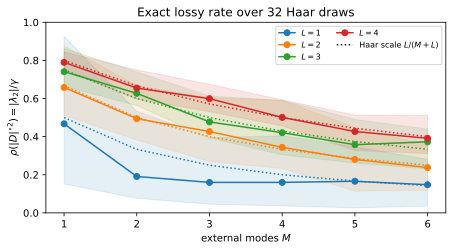

In [19]:
external_modes = np.arange(1, 7)
loop_modes = (1, 2, 3, 4)
haar_rates = {}
for L in loop_modes:
    for M in external_modes:
        values = []
        for sample in range(32):
            unitary = haar(M + L, 10000 * L + 100 * M + sample)
            Q = np.abs(unitary[M:, M:]) ** 2
            values.append(max(np.abs(np.linalg.eigvals(Q))))
        haar_rates[L, M] = np.array(values)

figure, axis = plt.subplots(figsize=(6.4, 3.6))
for L in loop_modes:
    samples = np.array([haar_rates[L, M] for M in external_modes])
    low, middle, high = np.quantile(samples, (.1, .5, .9), axis=1)
    line, = axis.plot(external_modes, middle, "o-", label=fr"$L={L}$")
    axis.fill_between(external_modes, low, high, alpha=.12,
                      color=line.get_color())
    axis.plot(external_modes, L / (external_modes + L), ":",
              color=line.get_color())
axis.plot([], [], "k:", label=r"Haar scale $L/(M+L)$")
axis.set_xlabel(r"external modes $M$")
axis.set_ylabel(r"$\rho(|D|^{\circ2})=|\lambda_2|/\gamma$")
axis.set_title("Exact lossy rate over 32 Haar draws")
axis.set_ylim(0, 1)
axis.legend(fontsize=8, ncol=2)
figure.tight_layout()
plt.show()


### The unroll length for a given noise level

Turning the bound into a number to use. With $|\lambda_2|\le\gamma$, reaching
total-variation error $\varepsilon$ needs at most

$$\boxed{\;n^\star(\gamma,\varepsilon)
=\left\lceil\frac{\log\varepsilon}{\log\gamma}\right\rceil
=\left\lceil\frac{\ln(1/\varepsilon)}{\ln(1/\gamma)}\right\rceil\;}$$

steps, for every $U$, $M$ and $L$. Writing the round-trip loss as
$\delta=1-\gamma$, the small-loss limit is

$$n^\star\;\approx\;\frac{\ln(1/\varepsilon)}{\delta}
\qquad(\delta\ll1),$$

so the depth is inversely proportional to the loss: halving the loss per round
trip doubles the unrolling needed, while the dependence on accuracy is only
logarithmic. Losing $5\%$ per round trip and asking for $10^{-6}$ costs a few
hundred steps; losing $1\%$ costs a few thousand.

The table below pairs that certificate with the depth actually needed by Haar
draws, to show how much slack the worst case carries.

In [20]:
def mixing_depth(chain, epsilon, cap=4000):
    values, vectors = np.linalg.eig(chain.T)
    stationary = np.real(vectors[:, np.argmin(np.abs(values - 1))])
    stationary = stationary / stationary.sum()
    state = np.zeros(len(chain))
    state[0] = 1.0
    for step in range(1, cap + 1):
        state = state @ chain
        if 0.5 * np.abs(state - stationary).sum() < epsilon:
            return step
    return None

losses = (0.99, 0.95, 0.9, 0.8, 0.5, 0.3)
targets = (1e-2, 1e-4, 1e-6)
bounds = {(g, e): int(np.ceil(np.log(e) / np.log(g)))
          for g in losses for e in targets}
observed = {}

print(" gamma  loss    eps      n* certified   n* observed (worst of 3)")
for gamma in losses:
    thinned = thinning(5, gamma, 1)
    chains = []
    for seed in (1, 2, 3):
        generator = np.random.default_rng(seed)
        chain = haar_chain(2, 1, 5, generator) @ thinned
        chains.append(chain / np.maximum(chain.sum(axis=1, keepdims=True), 1e-15))
    for epsilon in targets:
        worst = max(mixing_depth(c, epsilon) for c in chains)
        observed[gamma, epsilon] = worst
        print(f" {gamma:5.2f}  {1 - gamma:5.2f}  {epsilon:.0e}   {bounds[gamma, epsilon]:9d}"
              f"        {worst:9d}")


 gamma  loss    eps      n* certified   n* observed (worst of 3)


  0.99   0.01  1e-02         459               61
  0.99   0.01  1e-04         917              141
  0.99   0.01  1e-06        1375              221


  0.95   0.05  1e-02          90               34
  0.95   0.05  1e-04         180               83
  0.95   0.05  1e-06         270              133


  0.90   0.10  1e-02          44               20
  0.90   0.10  1e-04          88               52
  0.90   0.10  1e-06         132               84


  0.80   0.20  1e-02          21                9
  0.80   0.20  1e-04          42               27
  0.80   0.20  1e-06          62               45


  0.50   0.50  1e-02           7                3
  0.50   0.50  1e-04          14                8
  0.50   0.50  1e-06          20               15


  0.30   0.70  1e-02           4                2
  0.30   0.70  1e-04           8                5
  0.30   0.70  1e-06          12                8


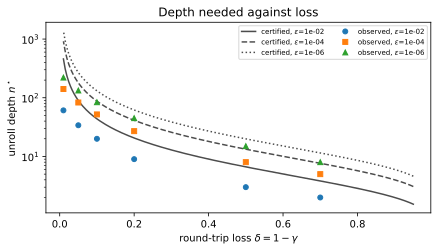

In [21]:
grid = np.linspace(0.05, 0.99, 200)
figure, axis = plt.subplots(figsize=(6.2, 3.6))
for epsilon, style in zip(targets, ("-", "--", ":")):
    axis.semilogy(1 - grid, np.log(epsilon) / np.log(grid), style,
                  color="0.3", label=fr"certified, $\varepsilon$={epsilon:.0e}")
for epsilon, marker in zip(targets, ("o", "s", "^")):
    axis.semilogy([1 - g for g in losses],
                  [observed[g, epsilon] for g in losses], marker,
                  ms=5, ls="none", label=fr"observed, $\varepsilon$={epsilon:.0e}")
axis.set_xlabel(r"round-trip loss $\delta = 1-\gamma$")
axis.set_ylabel(r"unroll depth $n^\star$")
axis.set_title("Depth needed against loss")
axis.legend(fontsize=7, ncol=2)
figure.tight_layout()
plt.show()


Both scale like $1/\delta$, and they are separated by a constant of about six:
at $\gamma=0.99$ the certificate asks for $1375$ steps to reach $10^{-6}$ while
these draws are converged by step $221$. That gap is slack in the *premise*
rather than in the bound — $|\lambda_2|\le\gamma$ allows a $U$ contributing no
mixing of its own, and a Haar-random one contributes plenty. So:

* use $n^\star(\gamma,\varepsilon)=\lceil\log\varepsilon/\log\gamma\rceil$ when
  the guarantee must hold for an arbitrary or adversarial $U$;
* expect several times less for a generic one, and use
  $\lceil\log\varepsilon/\log|\lambda_2|\rceil$ with the measured gap when the
  specific $U$ is in hand and its chain is affordable to build.

Either way $n^\star=O(\log(1/\varepsilon)/\delta)$, free of $M$ and $L$.

### The analytic $\eta$ bound and which certificate to use

The loss and Dobrushin certificates have different analytic dependences.
On the per-mode cutoff $0,\ldots,c-1$, pure thinning itself has the exact
coefficient

$$\boxed{\;\eta(B_{\gamma,c,L})
=1-(1-\gamma)^{L(c-1)}\;}.$$

Indeed, couple the photons shared by two input occupations and use the same
Bernoulli survival variables. The outputs can differ only if one of at most
$L(c-1)$ unmatched photons survives. This gives the upper bound, and the
vacuum and the maximally occupied state attain it. Submultiplicativity then
gives the computable composite bound

$$\boxed{\;\eta(PB_{\gamma,c,L})\le\eta(P)
\left[1-(1-\gamma)^{L(c-1)}\right]\;}.$$

$M$ and $U$ enter only through $\eta(P)$; no formula using $L,M,\gamma$
alone can capture their mixing. The cutoff formula also explains why one-step
$\eta$ deteriorates so quickly with $L$: for every fixed $\gamma>0$ it tends
to $1$ as either $L$ or $c$ grows, and on the unbounded Fock space
$\eta(B_\gamma)=1$. This does not contradict the useful loss certificate.
$\eta$ is a worst-case finite-time row separation, whereas
$\gamma\rho(|D|^{\circ2})$ is the asymptotic rate and $\gamma$ bounds it
uniformly. The sweep below checks both formulas and turns them into depths.

max |eta(B)-formula| = 1.1e-16
max positive eta-bound violation = 0.0e+00
 M  L   eta(.5)  eta(.9)  best/loss depth at .9
 1  1    0.3424    0.5873          0.197
 2  1    0.3683    0.4890          0.152
 3  1    0.2507    0.4122          0.121
 1  2    0.8122    0.9978          1.000
 2  2    0.6111    0.8933          0.932


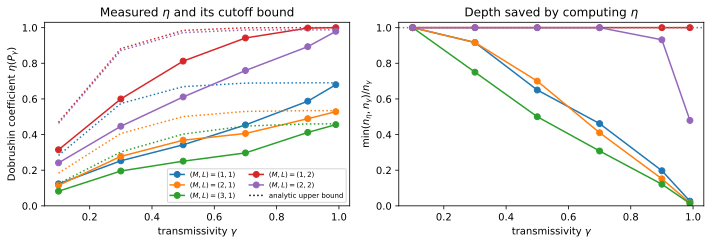

In [22]:
epsilon = 1e-6
gammas = np.array((.1, .3, .5, .7, .9, .99))
configurations = ((1, 1, 6), (2, 1, 5), (3, 1, 4),
                  (1, 2, 4), (2, 2, 4))
seeds = (11, 17, 23)

def depth_bound(rate, target):
    if rate <= 0:
        return 1
    if rate >= 1 - 1e-12:
        return np.inf
    return np.ceil(np.log(target) / np.log(rate))

def certificate_curve(M, L, cutoff, seed):
    chain, _ = seeded_chain(M, L, cutoff, seed)
    base_eta = dobrushin(chain)
    coefficients, upper, gains = [], [], []
    for gamma in gammas:
        loss = thinning(cutoff, gamma, L)
        lossy = chain @ loss
        lossy /= np.maximum(lossy.sum(axis=1, keepdims=True), 1e-15)
        coefficient = dobrushin(lossy)
        thinning_eta = 1 - (1 - gamma) ** (L * (cutoff - 1))
        eta_depth = depth_bound(coefficient, epsilon)
        loss_depth = depth_bound(gamma, epsilon)
        coefficients.append(coefficient)
        upper.append(base_eta * thinning_eta)
        gains.append(min(eta_depth, loss_depth) / loss_depth)
    return np.array(coefficients), np.array(upper), np.array(gains)

certificate_sweep = {}
for M, L, cutoff in configurations:
    curves = [certificate_curve(M, L, cutoff, seed) for seed in seeds]
    certificate_sweep[M, L] = tuple(
        np.array([curve[i] for curve in curves]) for i in range(3))

thinning_errors, bound_violations = [], []
for M, L, cutoff in configurations:
    coefficients, upper, _ = certificate_sweep[M, L]
    for j, gamma in enumerate(gammas):
        formula = 1 - (1 - gamma) ** (L * (cutoff - 1))
        thinning_errors.append(abs(dobrushin(
            thinning(cutoff, gamma, L)) - formula))
        bound_violations.extend(coefficients[:, j] - upper[:, j])

print(f"max |eta(B)-formula| = {max(thinning_errors):.1e}")
print("max positive eta-bound violation = "
      f"{max(0.0, max(bound_violations)):.1e}")
print(" M  L   eta(.5)  eta(.9)  best/loss depth at .9")
for M, L, _ in configurations:
    coefficients, _, gains = certificate_sweep[M, L]
    print(f" {M}  {L}    {np.median(coefficients[:, 2]):.4f}"
          f"    {np.median(coefficients[:, 4]):.4f}"
          f"          {np.median(gains[:, 4]):.3f}")

figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for M, L, _ in configurations:
    coefficients, upper, gains = certificate_sweep[M, L]
    middle = np.median(coefficients, axis=0)
    line, = axes[0].plot(gammas, middle, "o-",
                         label=fr"$(M,L)=({M},{L})$")
    axes[0].plot(gammas, np.median(upper, axis=0), ":",
                 color=line.get_color())
    axes[1].plot(gammas, np.median(gains, axis=0), "o-",
                 color=line.get_color())
axes[0].plot([], [], "k:", label=r"analytic upper bound")
axes[0].set_xlabel(r"transmissivity $\gamma$")
axes[0].set_ylabel(r"Dobrushin coefficient $\eta(P_\gamma)$")
axes[0].set_title(r"Measured $\eta$ and its cutoff bound")
axes[0].set_ylim(0, 1.03)
axes[0].legend(fontsize=7, ncol=2)
axes[1].axhline(1, ls=":", color="0.5")
axes[1].set_xlabel(r"transmissivity $\gamma$")
axes[1].set_ylabel(r"$\min(n_\eta,n_\gamma)/n_\gamma$")
axes[1].set_title(r"Depth saved by computing $\eta$")
axes[1].set_ylim(0, 1.03)
figure.tight_layout()
plt.show()


The sweep separates the dependencies that the two certificates hide.

* **$M$ acts through $U$.** For Haar $U$, increasing $M$ lowers both the
  typical exact rate and $\eta(P)$ because it opens more external escape
  ports. There is no worst-case $M$ improvement: an adversarial $U$ can still
  isolate the loop.
* **$L$ directly weakens one-step Dobrushin.** Its cutoff bound contains
  $L(c-1)$ in the exponent, so it rapidly approaches one. At
  $\gamma=0.9$ the $L=1$ chains save $80$--$88\%$ of the loss-bound depth,
  while the two $L=2$ chains save $0\%$ and $7\%$, even though their exact
  spectral rates remain well below one.
* **$\gamma$ is the uniform fallback.** It gives the finite depth
  $n_\gamma=\lceil\log\varepsilon/\log\gamma\rceil$ without building
  the chain, while the exact asymptotic rate is the smaller
  $\gamma\rho(|D|^{\circ2})$.

Thus compute $\eta$ only when the truncated population chain is already
affordable. Both certificates are valid simultaneously, so use
$n^\star=\min\{n^\star(\eta),n^\star(\gamma)\}$. When $\eta$
saturates or the Fock space is too large, $n^\star(\gamma)$ remains finite
and independent of $L$, $M$ and $U$.

### Can this be reduced to one-shot boson sampling?

Unrolling to depth $n$ is an ordinary linear-optical experiment on $O(nM)$
modes with $O(nM)$ photons, so stationary boson sampling is a *limit* of
ordinary boson sampling. The convergence result above says the error falls
like $|\lambda_2|^n$, so a target $\varepsilon$ needs
$n^\star=\log(1/\varepsilon)/\log(1/|\lambda_2|)$ steps — polynomial in
$\log(1/\varepsilon)$, but with a constant that diverges as $|\lambda_2|\to1$.

**Is stationary boson sampling reducible to one-shot boson sampling over
polynomially many more modes and photons?** Concretely: is
$|\lambda_2|$ bounded away from one by an inverse polynomial in $M$ and $L$
for generic $U$? If it is, then $n^\star=\mathrm{poly}(M,L)$ and the unrolled
experiment is a polynomial-size instance of ordinary boson sampling, placing
the stationary problem in the same complexity class. If instead the gap closes
super-polynomially for some family of $U$, the reduction fails and the
stationary problem is plausibly harder — which is what the reference
conjectures.

The lossy result above answers this for $\gamma<1$: **yes**, with
$n^\star=O(\log(1/\varepsilon))$ independent of $U$, $M$ and $L$. What remains open is
the lossless case, where the gap is $U$-dependent.

## Further reading

**The setup.** Yu. A. Biriukov and I. V. Dyakonov, [Simulation of boson
sampling with optical feedback](https://doi.org/10.48550/arXiv.2602.05566),
arXiv:2602.05566 (2026). For boson sampling itself, S. Aaronson and A.
Arkhipov, [The computational complexity of linear
optics](https://doi.org/10.1145/1993636.1993682), STOC 2011.

**The convergence analysis.** One step is a collision model: F. Ciccarello, S.
Lorenzo, V. Giovannetti and G. M. Palma, [Quantum collision models](
https://doi.org/10.1016/j.physrep.2022.01.001), Phys. Rep. **954** (2022).
Trace-norm contractivity of CPTP maps is in D. Pérez-García, M. M. Wolf, D.
Petz and M. B. Ruskai, [Contractivity of positive and trace-preserving maps
under $L_p$ norms](https://doi.org/10.1063/1.2218675), J. Math. Phys. **47**,
083506 (2006). That $|\lambda_2|$ alone does not bound finite-time
convergence for non-normal maps, and what to use instead, is O. Szehr, D. Reeb
and M. M. Wolf, [Spectral convergence bounds for classical and quantum Markov
processes](https://doi.org/10.1007/s00220-014-2188-5), Commun. Math. Phys.
**333**, 565–595 (2015).

**The bound.** The ergodicity coefficient is R. L. Dobrushin, *Central limit
theorem for non-stationary Markov chains*, Theory Probab. Appl. **1** (1956).
The quantum analogue used above as the route to a bound polynomial in $L$ is
A. Bakshi, A. Liu, A. Moitra and E. Tang, [A Dobrushin condition for quantum
Markov chains](https://doi.org/10.48550/arXiv.2510.08542), arXiv:2510.08542
(2025), to appear in STOC 2026.

**Part 1.** The loop is the unconditional counterpart of the heralded scheme
in Mendei, Homa, Ádám and Koniorczyk, [Photon number states via iterated
photon addition in a loop](https://doi.org/10.3390/photonics11111075),
*Photonics* **11**(11) 1075 (2024). That it cannot converge to the injected
Fock state is the Fock-state exception to quantum homogenization, M. Ziman et
al., [Phys. Rev. A **66**, 062307](https://doi.org/10.1103/PhysRevA.66.062307)
(2002).